# 08 — Price optimisation

*Prerequisite: notebooks 01–07.*

We now have an honest demand model. This notebook turns it into a price —
which is a different skill, and the one that decides whether any of the
previous work reaches a customer.

The mathematics of "maximise contribution" is a grid search: try every
price, keep the best. That takes four lines. The other 95% of the job is
everything around it:

- optimising the **right objective** (and knowing when profit is not it);
- respecting **constraints** that are real — stock, competitors, fairness,
  brand, the annual plan;
- handling the fact that your elasticity is an **estimate with error**, not
  a number;
- knowing when the answer is "don't move yet, buy information instead".

We will price the whole business, find where money is being left on the
table, then spend the rest of the notebook on the reasons a good pricing
manager would *not* implement the raw answer.

---

## The objective function

For a single quote, expected contribution is

```
E[contribution | margin m]  =  p(m)  ×  ( V·m/100  +  fees  −  cost to serve )
                               ↑          ↑
                        chance they buy   what we keep if they do
```

Two moving parts pulling in opposite directions. Raise `m`: the second
bracket grows linearly, `p(m)` shrinks. Profit is the product, so it rises,
peaks, and falls.

Aggregate that over quotes and you have the objective for a site, a segment
or the business. Notice what is **not** in it: fixed costs. Rent does not
change with price, so it cannot change the optimal price (notebook 02). If
your optimiser has an overhead allocation in it, delete the allocation, not
the optimiser.

We will rebuild the demand model at quote level — the notebook 05 logistic,
which we know recovers the truth — and use it as the engine.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from toolkit import INK, MUT, SUB, load, money, pct, style, tidy, truth
from toolkit import C as PALETTE

style()
rng = np.random.default_rng(3)

quotes = load("fct_quotes")
products = load("dim_products")
sites = load("dim_sites")
customers = load("dim_customers")
answer_key = truth()

df = quotes.copy()
df["log_order"] = np.log(df["order_value_gbp"] / 400)

model = smf.logit(
    "converted ~ C(segment) * quoted_margin_pp + C(segment) * comp_best_margin_pp "
    "+ season_z + log_order + loyalty_member + C(site_id)", data=df).fit(disp=0)

# the money attached to each quote, independent of the margin we choose
card_fee = df["product_id"].map(products.set_index("product_id")["card_fee_gbp"]).to_numpy()
value = df["order_value_gbp"].to_numpy()
is_online = df["channel"].eq("online").to_numpy()
is_card = df["product_id"].eq("TRAVEL_CARD").to_numpy()
is_collect = df["fulfilment"].eq("click_collect").to_numpy()
is_delivery = df["fulfilment"].eq("delivery").to_numpy()

variable_cost = (value * df["funding_cost_bp"].to_numpy() / 10000
                 + value * np.where(is_online, 0.009, 0.002)
                 + df["product_id"].map(products.set_index("product_id")["handling_cost_gbp"]).to_numpy()
                 + 0.90 * is_collect
                 + np.where(is_delivery & ~is_card, 4.50, 0.0)
                 + value * np.where(~is_online, 0.0055, np.where(is_collect, 0.0028, 0.0)))


# --- make the model fast to re-price with ---------------------------------
# Split every quote's log-odds into the part that does NOT depend on our
# margin ("context") and the margin slope for that customer's segment. Then
#     p(m) = 1 / (1 + exp(-(context + slope x m)))
# for any margin, with no design matrix to rebuild. That is the whole engine,
# and writing it out is also the clearest statement of what the model claims.

eta_observed = np.asarray(model.predict(df, which="linear"))
observed_margin = df["quoted_margin_pp"].to_numpy()

slope = np.full(len(df), model.params["quoted_margin_pp"])
for term, coefficient in model.params.items():
    if term.endswith(":quoted_margin_pp"):
        segment = term.split("[T.")[1].split("]")[0]
        slope[(df["segment"] == segment).to_numpy()] += coefficient
context = eta_observed - slope * observed_margin

fixed_money = card_fee * is_card - variable_cost      # £ per order, independent of the margin


def contribution_curve(margin_grid, mask=None, slope_factor=1.0):
    """Total expected contribution at each candidate margin, for a slice of the business."""
    idx = slice(None) if mask is None else mask
    s = slope[idx] * slope_factor
    c = eta_observed[idx] - s * observed_margin[idx]
    v, f = value[idx], fixed_money[idx]
    return np.array([(1 / (1 + np.exp(-(c + s * m))) * (v * m / 100 + f)).sum()
                     for m in margin_grid])


def expected_orders(margin_grid, mask=None):
    idx = slice(None) if mask is None else mask
    s, c = slope[idx], context[idx]
    return np.array([(1 / (1 + np.exp(-(c + s * m)))).sum() for m in margin_grid])


grid = np.round(np.arange(1.0, 9.01, 0.05), 2)
print(f"demand model fitted on {len(df):,} quotes; grid of {len(grid)} candidate margins")
print("segment margin slopes: " + ", ".join(
    f"{seg} {slope[(df['segment'] == seg).to_numpy()][0]:.2f}" for seg in sorted(df["segment"].unique())))

demand model fitted on 309,546 quotes; grid of 161 candidate margins
segment margin slopes: bargain_hunter -0.88, frequent_flyer -0.66, holiday_family -0.57, last_minute -0.32


## The profit curve, one site at a time

Start with the picture that should open every pricing paper you ever write:
contribution against price, with today's position marked on it.

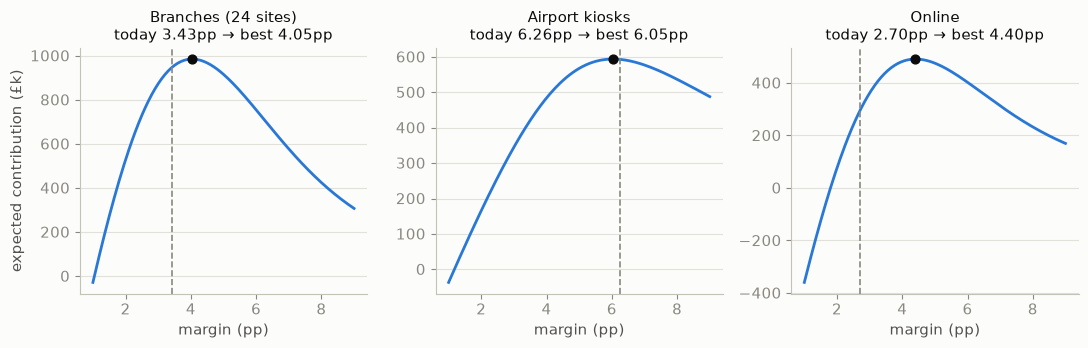

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharey=False)
for ax, channel, label in zip(axes, ["branch", "airport", "online"],
                              ["Branches (24 sites)", "Airport kiosks", "Online"]):
    mask = (df["channel"] == channel).to_numpy()
    curve = contribution_curve(grid, mask)
    today = observed_margin[mask].mean()
    best = grid[curve.argmax()]

    ax.plot(grid, curve / 1000, color=PALETTE[0])
    ax.axvline(today, color=MUT, ls="--", lw=1.2)
    ax.scatter([best], [curve.max() / 1000], color=INK, zorder=3, s=40)
    ax.set_title(f"{label}\ntoday {today:.2f}pp → best {best:.2f}pp", fontsize=10.5)
    ax.set_xlabel("margin (pp)")
    tidy(ax)
axes[0].set_ylabel("expected contribution (£k)")
plt.tight_layout()
plt.show()

In [3]:
rows = []
for channel in ["branch", "airport", "online"]:
    mask = (df["channel"] == channel).to_numpy()
    curve = contribution_curve(grid, mask)
    today = observed_margin[mask].mean()
    best = grid[curve.argmax()]
    now = contribution_curve([today], mask)[0]
    rows.append({
        "channel": channel,
        "quotes": int(mask.sum()),
        "today": round(today, 2),
        "our optimum": best,
        "truth": answer_key["optimal_uniform_margin_pp"]["by_channel"][channel],
        "move": round(best - today, 2),
        "contribution gain": curve.max() - now,
        "gain %": f"{curve.max() / now - 1:.0%}",
    })

opt = pd.DataFrame(rows)
print(opt.to_string(index=False))
years = df["date"].dt.year.nunique()
print(f"\ntotal prize: {money(opt['contribution gain'].sum())} across {years} years "
      f"= {money(opt['contribution gain'].sum() / years)} a year")

channel  quotes  today  our optimum  truth  move  contribution gain gain %
 branch  145549   3.43         4.05   4.05  0.62       36892.320813     4%
airport   56603   6.26         6.05   6.05 -0.21        1070.737867     0%
 online  107394   2.70         4.40   4.35  1.70      197727.790647    67%

total prize: £235,691 across 3 years = £78,564 a year


Three findings, and they are the sort a pricing manager gets hired to find.

**Online is underpriced by well over a point.** The channel with the largest
turnover earns the least per quote of the three, because its 0.9% card
acquiring fee and its fulfilment costs were never priced in. This is the
single largest prize in the business.

**The airport kiosks are slightly overpriced.** The one place everybody
"knows" you can charge what you like is charging just past its own peak: the
kiosks' mix is only half captive, and the other half is being driven away.

**The branches are a few tens of basis points light** — real money across 24
sites, but not a crisis. Which is worth saying out loud in the meeting,
because "most of the estate is priced sensibly" is what buys you credibility
for the recommendation that is not comfortable.

> **The optimiser found the money; it did not find the reasons.** Every one
> of these numbers has a story attached, and the story is what makes it
> actionable. "Raise online by 173bp" gets refused. "Online has never priced
> in its courier and card fees, so it earns £4.73 a transaction against a
> branch's £15.69 — here is the evidence, here is a 40bp test that already
> worked, here is a staged plan" gets approved.

## Constraints: why the raw answer is never the answer

The unconstrained optimum is an *input* to a decision, not the decision.
Five constraints bite in practice.

| Constraint | Where it comes from | Effect on the answer |
|---|---|---|
| **Competitive** | Never more than X above the best rival | Caps airport and online moves |
| **Capacity / stock** | You cannot sell notes you do not have | Raises the optimal price when stock binds |
| **Fairness & regulation** | Consumer Duty, vulnerable customers | Caps the captive-segment optimum (notebook 09) |
| **Brand & consistency** | "Same rate in every branch" promises | Forces a single price across different optima |
| **Volume / plan** | The annual plan says 60,000 orders | Trades profit for volume, explicitly |

The last one is worth doing properly, because it is the most common real
constraint and the one people handle worst — usually by arguing about it
rather than pricing it.

In [4]:
target_orders = 60000          # the annual plan, per year, whole business
years = df["date"].dt.year.nunique()

frontier = pd.DataFrame({"margin": grid,
                         "orders_per_year": expected_orders(grid) / years,
                         "contribution": contribution_curve(grid)})

unconstrained = frontier.loc[frontier["contribution"].idxmax()]
feasible = frontier[frontier["orders_per_year"] >= target_orders]
constrained = feasible.loc[feasible["contribution"].idxmax()]

today_orders = expected_orders([observed_margin.mean()])[0] / years
print(f"today (roughly)       : {observed_margin.mean():.2f}pp   {today_orders:,.0f} orders/yr")
print(f"unconstrained optimum : {unconstrained['margin']:.2f}pp   "
      f"{unconstrained['orders_per_year']:,.0f} orders/yr   {money(unconstrained['contribution'])}")
print(f"with a {target_orders:,}-order floor : {constrained['margin']:.2f}pp   "
      f"{constrained['orders_per_year']:,.0f} orders/yr   {money(constrained['contribution'])}")

cost_of_constraint = unconstrained["contribution"] - constrained["contribution"]
extra_orders = constrained["orders_per_year"] - unconstrained["orders_per_year"]
print(f"\nthe volume target costs {money(cost_of_constraint)} of contribution "
      f"to buy {extra_orders:,.0f} extra orders a year")
print(f"= {money(cost_of_constraint / max(extra_orders, 1) / years, 2)} per extra order — the shadow price")

today (roughly)       : 3.69pp   56,078 orders/yr
unconstrained optimum : 4.50pp   45,317 orders/yr   £1,991,238
with a 60,000-order floor : 3.40pp   60,153 orders/yr   £1,778,997

the volume target costs £212,240 of contribution to buy 14,836 extra orders a year
= £4.77 per extra order — the shadow price


Notice the size of that trade before reading on: the unconstrained optimum
sells roughly a quarter fewer orders than the business does today. Whatever
you think of the volume target, a plan that quietly shrinks the customer
base by 25% is not something to discover after implementation. This is why
volume constraints exist, and why the right response to one is arithmetic
rather than indignation.

### The shadow price ends the argument

That last number is the most useful output of any constrained optimisation.
It converts a disagreement about strategy into a price:

> *"Hitting the volume target costs us about £X of contribution per extra
> order. If an extra order is worth more than £X to us — because of lifetime
> value, or market share, or a supplier deal — then the target is correct
> and I will price for it. If it is worth less, we should change the
> target."*

Nobody has to win an argument about whether volume "matters". You have made
the trade explicit and handed the judgement to the people whose judgement it
is. That is what a good pricing analyst does with a constraint: not fight
it, not silently absorb it — **price it**.

## Uncertainty: optimising a number you do not know

Every price above came from an elasticity estimate with a confidence
interval. Pretending otherwise is how models lose credibility the first time
reality disagrees.

Two questions matter:

1. **How much does the recommendation move** if the elasticity is at the
   edge of its interval?
2. **How much does being wrong cost**, given the flat hilltop from notebook
   03?

Let's answer both by re-running the optimisation across the plausible range
of price sensitivity.

In [5]:
scenarios = {"pessimistic (customers 25% more sensitive)": 1.25,
             "central estimate": 1.00,
             "optimistic (customers 25% less sensitive)": 0.75}

branch_mask = (df["channel"] == "branch").to_numpy()
central_answer = grid[contribution_curve(grid, branch_mask).argmax()]

rows = []
for label, factor in scenarios.items():
    curve = contribution_curve(grid, branch_mask, slope_factor=factor)
    rows.append({"scenario": label,
                 "optimal margin": grid[curve.argmax()],
                 "contribution there": curve.max(),
                 "contribution at the central answer": curve[grid == central_answer][0]})

sens = pd.DataFrame(rows)
sens["cost of being wrong"] = sens["contribution there"] - sens["contribution at the central answer"]
sens["as % of the prize"] = (sens["cost of being wrong"] / sens["contribution there"]).map("{:.2%}".format)
for col in ["contribution there", "contribution at the central answer", "cost of being wrong"]:
    sens[col] = sens[col].map(lambda x: f"£{x:,.0f}")
print(f"The branch estate. Central recommendation: {central_answer:.2f}pp\n")
print(sens.to_string(index=False))

The branch estate. Central recommendation: 4.05pp

                                  scenario  optimal margin contribution there contribution at the central answer cost of being wrong as % of the prize
pessimistic (customers 25% more sensitive)            3.70           £950,616                           £935,328             £15,288             1.61%
                          central estimate            4.05           £985,023                           £985,023                  £0             0.00%
 optimistic (customers 25% less sensitive)            4.70         £1,066,877                         £1,039,424             £27,453             2.57%


Look at the final column. Even when the elasticity assumption is wrong by
25% in either direction, pricing at the central recommendation costs a small
fraction of the total — because the hilltop is flat.

This is the argument that gets a pricing model approved: **the decision is
robust even though the estimate is uncertain.** Not "trust the model" —
"here is what happens if the model is wrong, and it is survivable".

The complementary discipline is the **value of information**. If the
recommended move is worth £100k and the uncertainty could cost £15k, spend
two months testing before you move — the test is cheap. If the move is worth
£8k and the downside is £1k, run it and watch. Notebook 06's experiment
existed precisely because online was the biggest and least certain number in
the business.

## Evaluating a promotion properly

Promotions are price decisions with a marketing budget attached, and they
are evaluated worse than anything else in commerce. The standard mistake:

> "We ran the promotion, sales were up 17%, it worked."

Notebook 07 measured the true incremental effect of Meridian's summer
promotion. Now put money on it.

In [6]:
promo = answer_key["promotion"]
promo_quotes = df["promo_flag"] == 1
n_exposed = int(promo_quotes.sum())

# what the same quotes would have produced at the undiscounted rate
mask = promo_quotes.to_numpy()
m_promo = observed_margin[mask]


def sigmoid(z):
    return 1 / (1 + np.exp(-z))


with_promo = sigmoid(context[mask] + slope[mask] * m_promo)
without_promo = sigmoid(context[mask] + slope[mask] * (m_promo + 0.60))

v = value[mask]
vc = variable_cost[mask]

contribution_with = (with_promo * (v * m_promo / 100 - vc)).sum()
contribution_without = (without_promo * (v * (m_promo + 0.60) / 100 - vc)).sum()

print(f"quotes exposed to the promotion : {n_exposed:,}")
print(f"orders with promotion           : {with_promo.sum():,.0f}")
print(f"orders without (modelled)       : {without_promo.sum():,.0f}   "
      f"(+{with_promo.sum() / without_promo.sum() - 1:.1%} incremental)")
print(f"\ncontribution with promotion     : {money(contribution_with)}")
print(f"contribution without            : {money(contribution_without)}")
print(f"net effect of the promotion     : {money(contribution_with - contribution_without)}")
print(f"the truth                       : {money(promo['true_contribution_change_gbp'])}")

quotes exposed to the promotion : 3,032
orders with promotion           : 1,838
orders without (modelled)       : 1,566   (+17.4% incremental)

contribution with promotion     : £26,226
contribution without            : £27,257
net effect of the promotion     : £-1,031
the truth                       : £-1,264


The promotion **worked and was worthless**. It genuinely drove incremental
volume — this was not a case of discounting people who would have bought
anyway — and the extra volume almost exactly paid for the margin given away.
Three months of effort, signage, staff briefings and system changes to move
contribution by a rounding error.

That is the most common outcome of promotional activity, and it is
invisible unless you do this arithmetic. The break-even test from notebook
02 predicted it in advance: a branch runs about 3.1pp of contribution on
turnover, so a 60bp cut needs 0.6/(3.1−0.6) ≈ **+24% volume** to stand
still, and an elasticity of −26%/pp delivers about **+16%**. Two numbers on
an envelope, three months before the promotion ran, would have said "this
will be roughly neutral at best".

> **The three questions for any promotion**, in order:
> 1. **Incrementality** — would these customers have bought anyway?
> 2. **Break-even** — how much volume must it deliver, and is that plausible
>    given the elasticity we have measured?
> 3. **Contribution** — after variable costs on the extra volume, is there
>    anything left?
>
> Most promotions fail (2) on the back of an envelope. Failing (2) is a
> *finding*, not an objection: it tells marketing that the mechanism has to
> change — a fence, a threshold, a targeted offer — rather than the depth.

## The price that maximises this year is not the price that maximises the business

Everything above maximises contribution **on the quotes in front of us**.
But notebook 01 built one more mechanism into this world, and it is the one
most pricing models ignore:

> Customers who are quietly charged above the market rate for a year come
> back **less often** the next year. Specifically, every extra point above
> the best market rate costs about **12%** of that customer's trips.

Nothing in this year's P&L shows that. It arrives next year, as volume that
did not appear, and it will be blamed on the market.

**But do not take that coefficient on trust — estimate it.** We have three
years of customer history and an identifier that links them, which is
exactly the data this question needs and exactly the data most businesses
have thrown away.

The obvious approach is to compare each customer's trips next year with
their trips this year. It fails, and the way it fails is worth more than the
answer.

In [7]:
q = quotes.copy()
q["year"] = q["date"].dt.year
q["gap"] = q["quoted_margin_pp"] - q["comp_best_margin_pp"]
first, second = sorted(q["year"].unique())[:2]

exposure = (q[q["year"] == first].groupby("customer_id")
            .agg(gap=("gap", "mean"), trips_prev=("quote_id", "count")))
next_year = q[q["year"] == second].groupby("customer_id").size().rename("trips_next")
history = exposure.join(next_year).fillna({"trips_next": 0})
history = history[history["trips_prev"] > 0].join(
    customers.set_index("customer_id")["trips_per_year"])

naive = smf.ols("np.log((trips_next + 0.5) / trips_prev) ~ gap", data=history).fit()
modelled = smf.ols("I(trips_next / trips_per_year) ~ gap", data=history).fit()

print(f"customers with history in both years: {len(history):,}\n")
print("share of next year's trips lost per extra pp above the market:")
print(f"  controlling with LAST YEAR'S TRIPS : {-naive.params['gap']:.3f}")
print(f"  controlling with a MODELLED RATE   : {-modelled.params['gap']:.3f}")
print(f"  the truth                          : "
      f"{answer_key['retention']['margin_above_market_coefficient']:.3f}")

customers with history in both years: 29,876

share of next year's trips lost per extra pp above the market:
  controlling with LAST YEAR'S TRIPS : 0.026
  controlling with a MODELLED RATE   : 0.114
  the truth                          : 0.120


### Why the obvious estimator lost four fifths of the effect

Using last year's trips as the control recovers about a fifth of the truth.
That is not a coding error; it is **regression to the mean** from notebook
04, arriving where it does the most damage.

A customer who took four trips last year is partly a frequent traveller and
partly someone who had a busy year. The busy-year part does not repeat, so
their trips fall this year *regardless of what we charged them* — and that
fall is then attributed to whatever else is in the model. Because exposure
and trip count are computed from the same year, the noise contaminates the
comparison directly.

The fix is to control for the customer's **underlying** propensity rather
than a noisy realisation of it: a modelled expected trip rate from tenure,
segment and history — precisely what a CRM team's customer-value model
already produces. With that in place the estimate lands close to the truth.

> **The transferable rule:** whenever you control with a past realisation,
> you are controlling with something that contains noise, and the
> coefficient you care about gets dragged toward zero. Control with a
> *model* of the thing, not with one draw of it.

Now use the estimate — not the answer key — to value the customer over
several years instead of one transaction.

In [8]:
RETENTION_COEF = -modelled.params["gap"]       # estimated above, not assumed
DISCOUNT_RATE, HORIZON = 0.10, 4               # years of customer life we count

branch = (df["channel"] == "branch").to_numpy()
comp_here = df["comp_best_margin_pp"].to_numpy()


def lifetime_value(margin, mask):
    """This year's contribution, plus the discounted future it buys or destroys."""
    this_year = contribution_curve([margin], mask)[0] / df["date"].dt.year.nunique()
    above_market = max(0.0, margin - comp_here[mask].mean())
    retention = np.clip(1 - RETENTION_COEF * above_market, 0.5, 1.2)
    horizon_value = sum(this_year * retention ** t / (1 + DISCOUNT_RATE) ** t
                        for t in range(HORIZON))
    return this_year, retention, horizon_value


rows = []
for margin in np.arange(3.0, 5.51, 0.25):
    this_year, retention, lifetime = lifetime_value(margin, branch)
    rows.append({"margin": round(margin, 2), "contribution this year": this_year,
                 "retention next year": round(retention, 3),
                 "4-year value": lifetime})
horizon = pd.DataFrame(rows)

static_best = horizon.loc[horizon["contribution this year"].idxmax(), "margin"]
lifetime_best = horizon.loc[horizon["4-year value"].idxmax(), "margin"]
print(horizon.round(2).to_string(index=False))
print(f"\nbest margin ignoring retention : {static_best:.2f}pp")
print(f"best margin counting four years: {lifetime_best:.2f}pp")
print(f"the difference                 : {100 * (static_best - lifetime_best):.0f}bp of over-pricing "
      "you would never see in this year's numbers")

 margin  contribution this year  retention next year  4-year value
   3.00               291044.38                 1.00    1013827.05
   3.25               307362.31                 0.97    1029319.07
   3.50               318822.99                 0.94    1026366.29
   3.75               325683.92                 0.91    1007788.90
   4.00               328293.48                 0.88     976410.33
   4.25               327071.09                 0.86     934964.91
   4.50               322485.19                 0.83     886018.32
   4.75               315031.05                 0.80     831905.53
   5.00               305210.14                 0.77     774688.55
   5.25               293512.03                 0.74     716133.55
   5.50               280399.82                 0.72     657705.38

best margin ignoring retention : 4.00pp
best margin counting four years: 3.25pp
the difference                 : 75bp of over-pricing you would never see in this year's numbers


The lifetime-aware optimum sits **below** the one-year optimum. That gap is
the price of the customers you quietly lose, and three things follow.

**Every static price optimiser is biased upward.** Including the one earlier
in this notebook. If your model only sees this quarter's transactions, it
cannot see the customers who do not come back, so it will always recommend
a slightly-too-high price — and the error compounds, because next year's
optimiser runs on a base that has already been thinned.

**The correction is bigger for repeat businesses.** Our frequent flyers
travel five times a year; a family travels twice. The same 25bp costs the
first customer far more lifetime value than the second, which is a real
argument for differentiating by *frequency* rather than by willingness to
pay — and a much easier one to defend publicly.

**You can only make this argument with data nobody keeps.** It needs
customer identifiers linked across years. That is a data-engineering ask
made two years before the pricing question arrives, and it is exactly the
sort of thing a senior pricing manager should be pushing for while the
juniors are tuning models.

> **In the paper, say it like this:** *"The static optimum is X. Allowing
> for the repeat business we lose by pricing above market, the recommendation
> is X minus 25bp. I would rather be 25bp light and keep the base."*

## Price ladders, rounding and the last mile

The optimiser says 4.35pp. What actually goes on the board?

- **Round to the granularity the market reads.** Our rate board moves in 5bp
  steps. Fake precision (4.3742pp) signals a machine that nobody is
  supervising.
- **Keep the ladder coherent.** If EUR is 4.30 and USD is 4.55 with no
  reason a customer can perceive, expect to explain it. Internal consistency
  is a real constraint even when it costs a little money.
- **Watch psychological thresholds.** In consumer pricing, crossing a round
  number (£9.99 → £10.05) costs more volume than the arithmetic implies.
  In FX the equivalent is the *rate* the customer sees, not the spread you
  set — 1.1500 reads differently from 1.1498.
- **Move in steps, keep a holdout.** Two 40bp moves with a measurement
  between them are worth more than one 80bp move, because the first one
  tells you whether the second is a good idea.

## Practice

1. The optimiser says raise online by more than a point and a half. What
   are the three things you check before putting that in a paper?
2. Your volume constraint has a shadow price of about £4 per extra order
   and the average order carries about £11 of contribution. Is the
   constraint sensible?
3. A promotion delivers +17% volume and is contribution-neutral. Marketing
   proposes running it again, deeper. What is your recommendation?

<details>
<summary>Answers</summary>

1. (a) **Is the demand model trustworthy that far from observed prices?**
   The data contains almost no online quotes above 3.5pp, so 4.60pp is an
   extrapolation, and logistic models extrapolate confidently and wrongly.
   (b) **What do competitors charge?** A 4.60pp online rate against rivals
   at 3.0pp invites a share collapse the model cannot see, because our
   cross-price term was estimated in a narrow range. (c) **Can we test
   instead of decide?** The 40bp experiment made money; the disciplined path
   is another step and another measurement, not a leap.

2. Yes, comfortably — the constraint costs less per incremental order than
   an average order contributes, so the volume is cheap to buy. Flag it,
   price it, move on. The answer changes if the extra orders come
   disproportionately from the least profitable channel — always check
   *which* orders the constraint buys, because a volume target hit entirely
   through the thinnest-margin channel is a different decision from the same
   number hit across the estate.

3. Deeper is the wrong direction: contribution-neutral at 60bp means
   negative at 100bp, because the volume response is not steep enough to
   outrun the margin given away (the break-even requirement grows faster
   than the elasticity delivers). If the promotion has a purpose beyond
   contribution — acquiring customers who repeat, defending share during a
   rival's campaign — then measure *that* and justify it explicitly as an
   investment. Otherwise, change the mechanism: fence the discount to new
   customers, or to order sizes above a threshold, so the margin is given
   away only where it changes a decision.

</details>

---

**Next:** `09_segmentation_and_fairness.ipynb` — one price is a compromise.
What differentiated pricing is worth, and where the lines are.